Prepare data train/test

In [4]:
import os
import glob
import numpy as np
import tensorflow as tf
import joblib
import math
import random
from collections import Counter, defaultdict
import pandas as pd # <-- Thêm import

# Thư viện cho việc xử lý dữ liệu
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

2025-09-04 10:02:32.186859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756980152.427274      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756980152.498642      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:

# --- prepare data ---
def split_data_by_prefix(all_files, emotion_map, test_ratio=0.1, output_excel_path=None):
    """
    Chia dữ liệu với điều kiện mới: cụm < 10 file sẽ không được lấy vào tập test.
    """
    # Bước 1: Nhóm tất cả các file theo (nhãn, 2-ký-tự-đầu)
    grouped_files = defaultdict(lambda: defaultdict(list))
    for file_path in all_files:
        try:
            folder_name = os.path.basename(os.path.dirname(file_path))
            label = emotion_map[folder_name]
            filename = os.path.basename(file_path)
            prefix = filename[:2]
            grouped_files[label][prefix].append(file_path)
        except (KeyError, IndexError):
            print(f"Bỏ qua file không hợp lệ hoặc không có trong emotion_map: {file_path}")
            continue

    # Bước 2: Duyệt qua từng cụm đã nhóm và chia train/test
    data_train = []
    data_test = []

    for label in grouped_files:
        for prefix in grouped_files[label]:
            file_cluster = grouped_files[label][prefix]
            
            # --- THAY ĐỔI LOGIC TẠI ĐÂY ---
            # Nếu cụm có ít hơn 10 file, đưa tất cả vào tập train
            if len(file_cluster) < 7:
                data_train.extend(file_cluster)
            else:
                # Nếu cụm có từ 10 file trở lên, áp dụng quy tắc chia cũ
                random.shuffle(file_cluster)
                n_test = math.ceil(len(file_cluster) * test_ratio)
                
                test_files = file_cluster[:n_test]
                train_files = file_cluster[n_test:]
                
                data_test.extend(test_files)
                data_train.extend(train_files)


    # Xuất ra file Excel nếu có yêu cầu
    if output_excel_path:
        try:
            df_train = pd.DataFrame(data_train, columns=['filepath'])
            df_test = pd.DataFrame(data_test, columns=['filepath'])
            with pd.ExcelWriter(output_excel_path) as writer:
                df_train.to_excel(writer, sheet_name='data_train', index=False)
                df_test.to_excel(writer, sheet_name='data_test', index=False)
            print(f"Đã xuất danh sách train và test ra file: {output_excel_path}")
        except Exception as e:
            print(f"Lỗi khi xuất file Excel: {e}")

    return data_train, data_test



In [7]:
data_train = ""
data_test = ""

In [ ]:
import pandas as pd

def load_split_data_from_excel(excel_path):
    
    try:
        
        df_train = pd.read_excel(excel_path, sheet_name='data_train')
        df_test = pd.read_excel(excel_path, sheet_name='data_test')

        data_train_paths = df_train['filepath'].tolist()
        data_test_paths = df_test['filepath'].tolist()
        
        print(f"Load {len(data_train_paths)} path file train.")
        print(f"Load {len(data_test_paths)} path file test.")
        
        return data_train_paths, data_test_paths

    except FileNotFoundError:
        print(f"Error: file not found '{excel_path}'")
        return None, None
    except Exception as e:
        print(f"Error read file Excel: {e}")
        return None, None


In [1]:
EMOTIONS = ['Angry', 'Happy', 'Fear', 'Neutral', 'Sad', 'Boredom', 'Disgust']
NUM_CLASSES = len(EMOTIONS)
emotion_map = {
    'Angry': 0, 
    'Happy': 1, 
    'Fear': 2, 
    'Neutral': 3, 
    'Sad': 4, 
    'Boredom': 5, 
    'Disgust': 6
}

# --- Bước 1: Tải và phân chia dữ liệu ---
#root_folder = '/kaggle/input/speech-emotion-10/EmoDB/EmoDB'
#folders = [f for f in glob.glob(os.path.join(root_folder, "*")) if os.path.isdir(f)]
#all_files = []
#for folder in folders:
#    files = glob.glob(os.path.join(folder, "**", "*.wav"), recursive=True)
#    all_files.extend(files)

#if not all_files:
#    raise ValueError("No audio files found in the source directory.")

#print(f"Total files found: {len(all_files)}")

# Sử dụng hàm chia dữ liệu tùy chỉnh theo quy tắc mới
#print("Splitting data based on custom prefix rule...")
#data_train, data_test = split_data_by_prefix(all_files, emotion_map, test_ratio=0.1, output_excel_path='data_split_results.xlsx')

STACN + data augmentation

Prepare Test/Validation data (No Augmentation): 100%|██████████| 61/61 [00:00<00:00, 81.52it/s]


Model: "STACN_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 157, 78)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 157, 128)  │     10,112 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 157, 128)  │        512 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 157, 128)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 157, 128)  │          0 │ leaky_re_lu_6[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 157, 128)  │     16,512 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 157, 128)  │        512 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 157, 128)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 157, 128)  │          0 │ leaky_re_lu_7[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 157, 128)  │    263,808 │ dropout_17[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_17[0][0], │
│                     │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 157, 32)   │     12,320 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 157, 32)   │        128 │ conv1d_21[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 157, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_6 │ (None, 157, 32)   │          0 │ re_lu_6[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 157, 32)   │      3,104 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 157, 32)   │        128 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 157, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_7 │ (None, 157, 32)   │          0 │ re_lu_7[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,951,479 (18.89 MB)

 Trainable params: 4,950,839 (18.89 MB)

 Non-trainable params: 640 (2.50 KB)


==================== BẮT ĐẦU HUẤN LUYỆN ====================
Epoch 1/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2636 - loss: 1.8263
Epoch 1: val_loss improved from inf to 1.36338, saving model to stacn_best_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.2641 - loss: 1.8250 - val_accuracy: 0.4583 - val_loss: 1.3634 - learning_rate: 1.0000e-04
Epoch 2/200
129/134 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5173 - loss: 1.2239
Epoch 2: val_loss improved from 1.36338 to 1.08403, saving model to stacn_best_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5183 - loss: 1.2213 - val_accuracy: 0.5625 - val_loss: 1.0840 - learning_rate: 1.0000e-04
Epoch 3/200
130/134 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6263 - loss: 0.9397
Epoch 3: val_loss improved from 1.08403 to 0.90807, saving model to stacn_best_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6263 - loss: 0.9392 - val_accuracy: 0.6042 - val_loss: 0.9

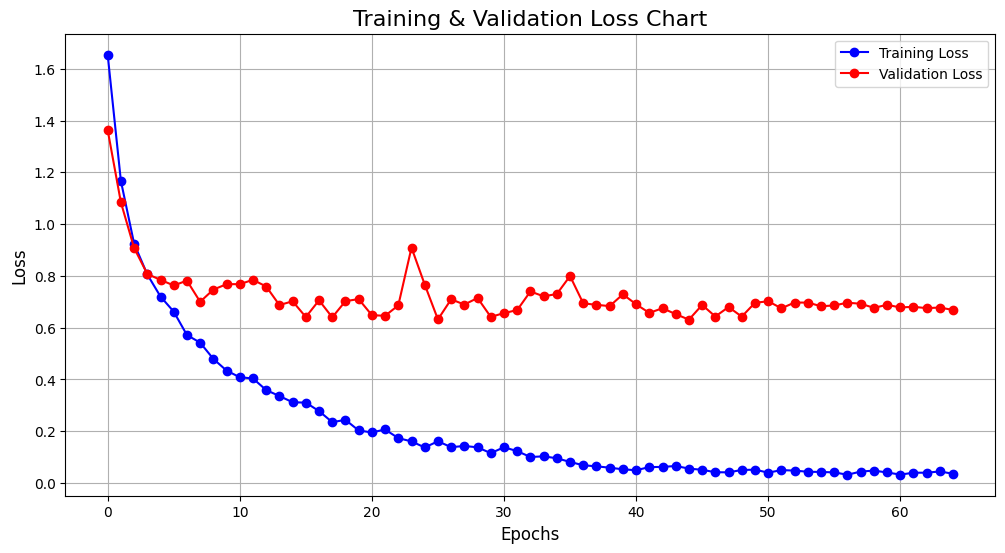

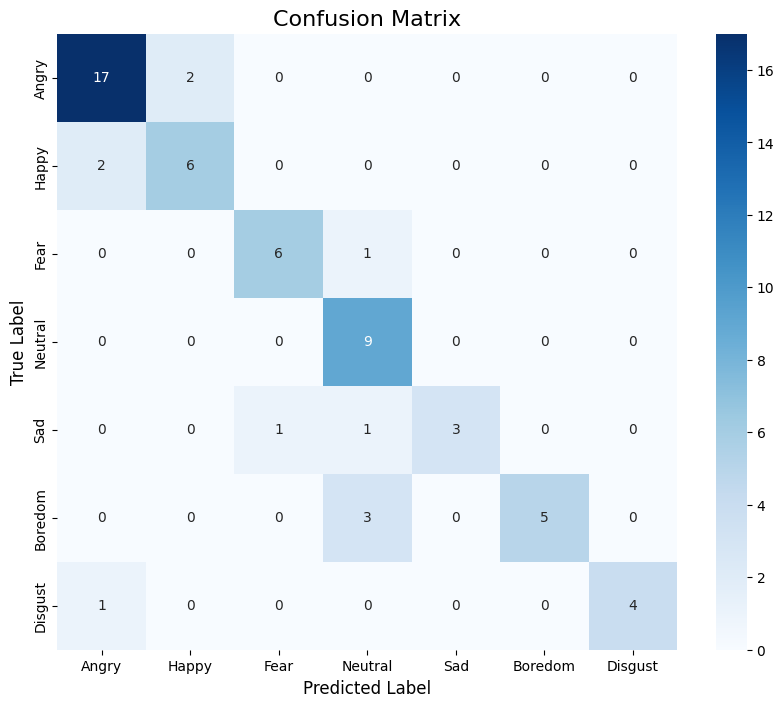

In [15]:
import os
import numpy as np
import pandas as pd
import librosa
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# =============================================================================
# PHẦN 1: CÀI ĐẶT VÀ CÁC HÀM TIỀN XỬ LÝ
# (Giữ nguyên không thay đổi)
# =============================================================================

# --- Các hằng số ---
EMOTIONS = ['Angry', 'Happy', 'Fear', 'Neutral', 'Sad', 'Boredom', 'Disgust']
NUM_CLASSES = len(EMOTIONS)
emotion_map = {
    'Angry': 0, 'Happy': 1, 'Fear': 2, 'Neutral': 3,
    'Sad': 4, 'Boredom': 5, 'Disgust': 6
}
SAMPLE_RATE = 16000
DURATION = 8
N_FRAMES = 157

# --- Các hàm Augmentation ---
def add_noise(audio, noise_factor=0.01):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise
def pitch_shift(audio, sr, n_steps=2):
    return librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)
def time_stretch(audio, rate=0.95):
    return librosa.effects.time_stretch(y=audio, rate=rate)
def time_shift(audio, shift_max=0.15, sr=SAMPLE_RATE):
    shift = int(np.random.uniform(-shift_max, shift_max) * sr)
    return np.roll(audio, shift)

# --- Hàm trích xuất đặc trưng ---
def extract_features(audio_path, sample_rate=SAMPLE_RATE, duration=DURATION, n_mfcc=26, n_frames=N_FRAMES, augment_type='normal'):
    try:
        audio, sr = librosa.load(audio_path, sr=sample_rate)
        target_length = sample_rate * duration
        if len(audio) < target_length: audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else: audio = audio[:target_length]
        if augment_type == 'noise': audio = add_noise(audio)
        elif augment_type == 'pitch': audio = pitch_shift(audio, sr)
        elif augment_type == 'stretch': audio = time_stretch(audio)
        elif augment_type == 'shift': audio = time_shift(audio)
        hop_length = target_length // (n_frames - 1)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        features = np.vstack((mfcc, mfcc_delta, mfcc_delta2))
        if features.shape[1] < n_frames: features = np.pad(features, ((0, 0), (0, n_frames - features.shape[1])), mode='constant')
        else: features = features[:, :n_frames]
        return features.T
    except Exception:
        return None

# =============================================================================
# PHẦN 2: KIẾN TRÚC MÔ HÌNH STACN
# =============================================================================
def feature_mapping_block(inputs, dropout_rate=0.2):
    x = layers.Dense(128)(inputs); x = layers.BatchNormalization()(x); x = layers.LeakyReLU()(x); x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128)(x); x = layers.BatchNormalization()(x); x = layers.LeakyReLU()(x); x = layers.Dropout(dropout_rate)(x)
    return x
def temporal_aware_block(inputs, filters=32, kernel_size=3, dilation_rate=2):
    residual = inputs
    x = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(inputs); x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.SpatialDropout1D(0.2)(x)
    gate = layers.Activation('sigmoid')(x)
    if residual.shape[-1] != filters: residual = layers.Conv1D(filters, 1, padding='same')(residual)
    return layers.multiply([residual, gate])
def residual_module(inputs):
    residual = inputs
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inputs)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    residual = layers.Conv1D(256, 1, padding='same')(residual)
    return layers.add([x, residual])
class CapsuleLayer(layers.Layer):
    def __init__(self, num_capsule, dim_capsule, routings=3, **kwargs):
        super(CapsuleLayer, self).__init__(**kwargs)
        self.num_capsule, self.dim_capsule, self.routings = num_capsule, dim_capsule, routings
    def build(self, input_shape):
        self.input_num_capsule, self.input_dim_capsule = input_shape[1], input_shape[2]
        self.W = self.add_weight(shape=[self.num_capsule, self.input_num_capsule, self.dim_capsule, self.input_dim_capsule], initializer='glorot_uniform', name='W')
    def call(self, inputs, training=None):
        u_hat = tf.einsum('bik,jilk->bjil', inputs, self.W); b = tf.zeros(shape=[tf.shape(inputs)[0], self.num_capsule, self.input_num_capsule, 1]); v = None
        for i in range(self.routings):
            c = tf.nn.softmax(b, axis=1); s = tf.reduce_sum(c * u_hat, axis=2); v = self.squash(s)
            if i < self.routings - 1: v_tiled = tf.expand_dims(v, axis=2); agreement = tf.reduce_sum(u_hat * v_tiled, axis=3, keepdims=True); b += agreement
        return v
    def squash(self, vectors, axis=-1):
        s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
        scale = s_squared_norm / (1 + s_squared_norm) / tf.sqrt(s_squared_norm + K.epsilon())
        return scale * vectors
def create_stacn_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    fm_output = feature_mapping_block(inputs); mha_output = layers.MultiHeadAttention(num_heads=8, key_dim=64)(query=fm_output, value=fm_output, key=fm_output)
    tab_output = temporal_aware_block(mha_output); res_output = residual_module(tab_output)
    capsule_output = CapsuleLayer(num_capsule=NUM_CLASSES, dim_capsule=16, routings=3)(res_output)
    flatten_output = layers.Flatten()(capsule_output); outputs = layers.Dense(NUM_CLASSES, activation='softmax')(flatten_output)
    return models.Model(inputs=inputs, outputs=outputs, name="STACN_Model")

# =============================================================================
# PHẦN 3: CÁC HÀM HỖ TRỢ HUẤN LUYỆN VÀ ĐÁNH GIÁ
# =============================================================================
def prepare_training_data(audio_files, emotion_map):
    X, y = [], []
    augment_types = ['normal', 'noise', 'pitch', 'stretch', 'shift']
    for audio_path in tqdm(audio_files, desc="Prepare Train data (Augmentation)"):
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map: continue
        emotion_idx = emotion_map[folder_name]
        for aug_type in augment_types:
            features = extract_features(str(audio_path), augment_type=aug_type)
            if features is not None: X.append(features); y.append(emotion_idx)
    return np.array(X), to_categorical(y, num_classes=NUM_CLASSES)

def prepare_test_data(audio_files, emotion_map):
    X, y = [], []
    for audio_path in tqdm(audio_files, desc="Prepare Test/Validation data (No Augmentation)"):
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map: continue
        emotion_idx = emotion_map[folder_name]
        features = extract_features(str(audio_path), augment_type='normal')
        if features is not None: X.append(features); y.append(emotion_idx)
    return np.array(X), to_categorical(y, num_classes=NUM_CLASSES)

def plot_loss_history(history):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], 'bo-', label='Training Loss')
    plt.plot(history.history['val_loss'], 'ro-', label='Validation Loss')
    plt.title('Training & Validation Loss Chart', fontsize=16)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix", fontsize=16) 
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()


# =============================================================================
# PHẦN 4: CHẠY THỰC THI (MAIN BLOCK - ĐÃ XÓA K-FOLD)
# =============================================================================

if __name__ == '__main__':
    

        # Chia thành tập train_val (90%) và tập test cuối cùng (10%)
        train_val_files = data_train
        test_files = data_test

        # Chia tập train_val thành tập train (90%) và tập validation (10%)
        y_stratify_train_val = [emotion_map.get(os.path.basename(os.path.dirname(f))) for f in train_val_files]
        train_files, val_files = train_test_split(train_val_files, test_size=0.1, random_state=42, stratify=y_stratify_train_val)
        
        # --- BƯỚC 2: Chuẩn bị dữ liệu ---
        X_train, y_train = prepare_training_data(train_files, emotion_map)
        X_val, y_val = prepare_test_data(val_files, emotion_map)
        X_test, y_test = prepare_test_data(test_files, emotion_map)

        # --- BƯỚC 3: Chuẩn hóa dữ liệu ---
        scaler = StandardScaler()
        X_train_shape, X_val_shape, X_test_shape = X_train.shape, X_val.shape, X_test.shape
        X_train = scaler.fit_transform(X_train.reshape(-1, X_train_shape[-1])).reshape(X_train_shape)
        X_val = scaler.transform(X_val.reshape(-1, X_val_shape[-1])).reshape(X_val_shape)
        X_test = scaler.transform(X_test.reshape(-1, X_test_shape[-1])).reshape(X_test_shape)

        # --- BƯỚC 4: Huấn luyện mô hình ---
        input_shape = (X_train.shape[1], X_train.shape[2])
        model = create_stacn_model(input_shape)
        model.summary()
        
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
        
        checkpoint_path = "stacn_best_model.keras"
        early_stopping = EarlyStopping(monitor='val_loss', patience=20, verbose=1, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)
        checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1)

        print(f"\n{'='*20} BẮT ĐẦU HUẤN LUYỆN {'='*20}")
        history = model.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=200,
                            batch_size=16,
                            callbacks=[early_stopping, reduce_lr, checkpoint],
                            verbose=1)
        
        # --- BƯỚC 5: Đánh giá mô hình cuối cùng trên tập Test ---
        print(f"\n\n{'='*20} ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST {'='*20}")
        best_model = models.load_model(checkpoint_path, custom_objects={'CapsuleLayer': CapsuleLayer})
        
        y_pred_test = best_model.predict(X_test)
        y_pred_classes_test = np.argmax(y_pred_test, axis=1)
        y_true_classes_test = np.argmax(y_test, axis=1)
        
        print("\nClassification Report:")
        print(classification_report(y_true_classes_test, y_pred_classes_test, target_names=EMOTIONS, zero_division=0))
        
        # Vẽ biểu đồ và ma trận nhầm lẫn
        plot_loss_history(history)
        plot_confusion_matrix(y_true_classes_test, y_pred_classes_test, EMOTIONS)